In [4]:
# Gaussian-process regression for foam property prediction
# Train one GPR model per response, evaluate leave-one-out performance,
# and compare predictions against the measured formulation data.

In [5]:
# import data

from pathlib import Path
import pandas as pd

# Load the compiled data
project_root = Path.cwd().resolve().parent if 'notebooks' in str(Path.cwd()) else Path.cwd().resolve()
excel_path = project_root / 'data' / 'raw' / 'Compiled Data.xlsx'

df = pd.read_excel(excel_path)

print()

In [6]:
# Show the 25 original formulas and their three measured targets from df.
formula_cols = ["TEM", "Joncryl", "NC513", "PEG-DE", "NGDE"]
measured_target_cols = [
    "Avg_Density_g_cm3",
    "24h_avg_pct absorption",
    "24h_avg_pct_retention",
]
raw_data_summary = df[formula_cols + measured_target_cols].copy()
raw_data_summary[formula_cols] = raw_data_summary[formula_cols].fillna(0.0)
raw_data_summary[measured_target_cols] = raw_data_summary[measured_target_cols].apply(
    pd.to_numeric, errors="raise"
)

assert len(raw_data_summary) == 25, (
    f"Expected the 25 original samples; found {len(raw_data_summary)}."
)
display(raw_data_summary)

,TEM,Joncryl,NC513,PEG-DE,NGDE,Avg_Density_g_cm3,24h_avg_pct absorption,24h_avg_pct_retention
0,8,0.0,0.0,0.0,0.0,0.192000,113.616943,31.770000
1,8,0.7,0.0,0.0,0.0,0.195000,103.817309,33.120000
2,8,1.0,0.0,0.0,0.0,0.159000,129.464292,36.250000
3,8,1.5,0.0,0.0,0.0,0.159933,120.749405,25.330000
4,8,2.0,0.0,0.0,0.0,0.201000,113.871581,26.580000
5,8,3.0,0.0,0.0,0.0,0.202000,111.044347,27.400000
6,5,0.0,0.0,0.0,0.0,0.298930,56.958538,36.614852
7,5,0.0,0.7,0.0,0.0,0.360035,57.115160,44.587460
8,5,0.0,1.0,0.0,0.0,0.355557,44.308895,43.766577
9,5,0.0,2.0,0.0,0.0,0.358055,43.326301,44.186536


In [7]:
# Train one Gaussian process regressor per target, using LOOCV on all 25 samples.
import numpy as np
from sklearn.base import clone
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

feature_cols = ["TEM", "Joncryl", "NC513", "PEG-DE", "NGDE"]
target_cols = [
    "Avg_Density_g_cm3",
    "24h_avg_pct absorption",
    "24h_avg_pct_retention",
]

# Blank ingredient cells mean that ingredient was not used in the formula.
model_data = df[feature_cols + target_cols].copy()
model_data[feature_cols] = model_data[feature_cols].fillna(0.0)
model_data[target_cols] = model_data[target_cols].apply(pd.to_numeric, errors="raise")

assert len(model_data) == 25, f"Expected all 25 samples; found {len(model_data)}."
assert not model_data[target_cols].isna().any().any(), "A target contains missing values."

X = model_data[feature_cols]
loo = LeaveOneOut()
gpr_models = {}
cv_predictions = pd.DataFrame(index=model_data.index)
results = []

for target in target_cols:
    y = model_data[target]
    kernel = (
        ConstantKernel(1.0, (1e-3, 1e3))
        * Matern(
            length_scale=np.ones(len(feature_cols)),
            length_scale_bounds=(1e-2, 1e3),
            nu=2.5,
        )
        + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-8, 1e1))
    )
    estimator = make_pipeline(
        StandardScaler(),
        GaussianProcessRegressor(
            kernel=kernel,
            normalize_y=True,
            n_restarts_optimizer=5,
            random_state=42,
        ),
    )

    # cross_val_predict clones and refits the estimator for every held-out sample.
    oof_prediction = cross_val_predict(clone(estimator), X, y, cv=loo, n_jobs=1)
    cv_predictions[f"{target} - LOOCV prediction"] = oof_prediction

    # Fit the final deployable model on all 25 observations; GPR optimizes kernel
    # hyperparameters by maximizing the log marginal likelihood during fit.
    final_model = clone(estimator).fit(X, y)
    gpr_models[target] = final_model

    results.append(
        {
            "target": target,
            "LOOCV R2": r2_score(y, oof_prediction),
            "LOOCV MAE": mean_absolute_error(y, oof_prediction),
            "LOOCV RMSE": np.sqrt(mean_squared_error(y, oof_prediction)),
            "optimized kernel (all 25 samples)": str(
                final_model.named_steps["gaussianprocessregressor"].kernel_
            ),
        }
    )

results_df = pd.DataFrame(results).set_index("target")
print("LOOCV performance:")
display(results_df)
print("\nFirst five out-of-fold predictions:")
display(cv_predictions.head())

c:\Users\Brooke Brocker\foam-project\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 3 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\Brooke Brocker\foam-project\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 3 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\Brooke Brocker\foam-project\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 3 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\Brooke Bro

LOOCV performance:


c:\Users\Brooke Brocker\foam-project\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


,LOOCV R2,LOOCV MAE,LOOCV RMSE,optimized kernel (all 25 samples)
target,,,,
Avg_Density_g_cm3,0.865830,0.018787,0.023439,"0.973**2 * Matern(length_scale=[0.232, 1.22, 1..."
24h_avg_pct absorption,0.859557,22.804300,29.089821,"0.907**2 * Matern(length_scale=[3.26, 2.2, 4.5..."
24h_avg_pct_retention,0.734585,5.016151,6.683205,"1.06**2 * Matern(length_scale=[8.06, 0.563, 1...."



First five out-of-fold predictions:


,Avg_Density_g_cm3 - LOOCV prediction,24h_avg_pct absorption - LOOCV prediction,24h_avg_pct_retention - LOOCV prediction
0,0.204338,140.073728,29.026324
1,0.164137,126.649184,31.170363
2,0.165689,110.308253,38.659445
3,0.163207,134.446643,32.554296
4,0.165964,110.056105,28.515628


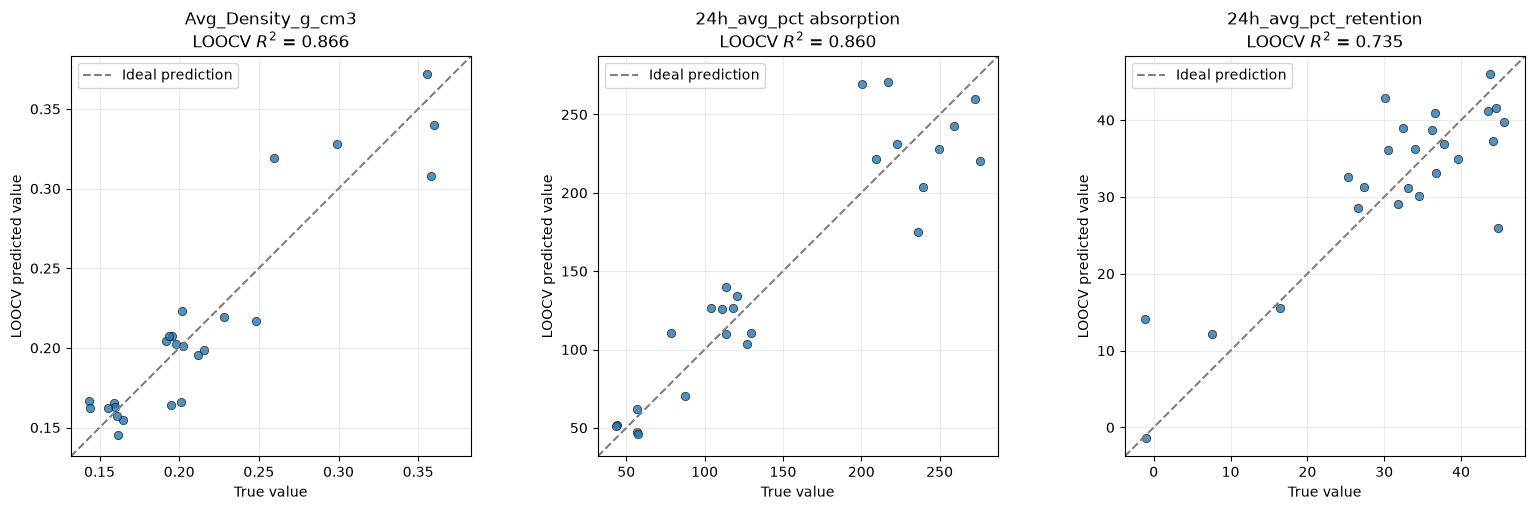

In [8]:
# Compare leave-one-out predictions with the measured values for each target.
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(target_cols), figsize=(16, 5))

for ax, target in zip(axes, target_cols):
    y_true = model_data[target]
    y_pred = cv_predictions[f"{target} - LOOCV prediction"]
    score = r2_score(y_true, y_pred)
    lower = min(y_true.min(), y_pred.min())
    upper = max(y_true.max(), y_pred.max())
    padding = (upper - lower) * 0.05
    plot_min, plot_max = lower - padding, upper + padding

    ax.scatter(y_true, y_pred, alpha=0.8, edgecolor="black", linewidth=0.5)
    ax.plot([plot_min, plot_max], [plot_min, plot_max], "--", color="gray", label="Ideal prediction")
    ax.set_xlim(plot_min, plot_max)
    ax.set_ylim(plot_min, plot_max)
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(f"{target}\nLOOCV $R^2$ = {score:.3f}")
    ax.set_xlabel("True value")
    ax.set_ylabel("LOOCV predicted value")
    ax.grid(alpha=0.25)
    ax.legend()

fig.tight_layout()
plt.show()

In [9]:
# Interactive 3D comparison of measured outcomes and GPR LOOCV predictions.
import plotly.graph_objects as go

measured_values = model_data[target_cols].to_numpy(dtype=float)
predicted_values = cv_predictions[
    [f"{target} - LOOCV prediction" for target in target_cols]
].to_numpy(dtype=float)
formula_values = model_data[feature_cols].to_numpy(dtype=float)

# Draw connectors first so the measured and predicted markers remain prominent.
connector_x, connector_y, connector_z = [], [], []
for measured, predicted in zip(measured_values, predicted_values):
    connector_x.extend([measured[0], predicted[0], None])
    connector_y.extend([measured[1], predicted[1], None])
    connector_z.extend([measured[2], predicted[2], None])

fig = go.Figure()
fig.add_trace(
    go.Scatter3d(
        x=connector_x,
        y=connector_y,
        z=connector_z,
        mode="lines",
        line=dict(color="gray", width=2),
        opacity=0.35,
        hoverinfo="skip",
        showlegend=False,
        name="Prediction error",
    )
)

formula_hover = [
    "<br>".join(f"{name}: {value:g}" for name, value in zip(feature_cols, formula))
    for formula in formula_values
]

fig.add_trace(
    go.Scatter3d(
        x=measured_values[:, 0],
        y=measured_values[:, 1],
        z=measured_values[:, 2],
        mode="markers",
        name="Measured",
        marker=dict(size=6, color="#1769aa", symbol="circle", opacity=0.9),
        text=formula_hover,
        hovertemplate=(
            "<b>Measured</b><br>Density: %{x:.3f} g/cm^3"
            "<br>Absorption: %{y:.2f}%<br>Retention: %{z:.2f}%"
            "<br>%{text}<extra></extra>"
        ),
    )
)
fig.add_trace(
    go.Scatter3d(
        x=predicted_values[:, 0],
        y=predicted_values[:, 1],
        z=predicted_values[:, 2],
        mode="markers",
        name="GPR LOOCV prediction",
        marker=dict(size=6, color="#e87519", symbol="diamond", opacity=0.9),
        text=formula_hover,
        hovertemplate=(
            "<b>LOOCV prediction</b><br>Density: %{x:.3f} g/cm^3"
            "<br>Absorption: %{y:.2f}%<br>Retention: %{z:.2f}%"
            "<br>%{text}<extra></extra>"
        ),
    )
)

fig.update_layout(
    title="Measured outcomes vs. GPR LOOCV predictions",
    scene=dict(
        xaxis_title="Density (g/cm^3)",
        yaxis_title="24 h absorption (%)",
        zaxis_title="24 h retention (%)",
        aspectmode="data",
    ),
    height=700,
    margin=dict(l=0, r=0, b=0, t=55),
    legend=dict(x=0.02, y=0.98),
)
fig.show()

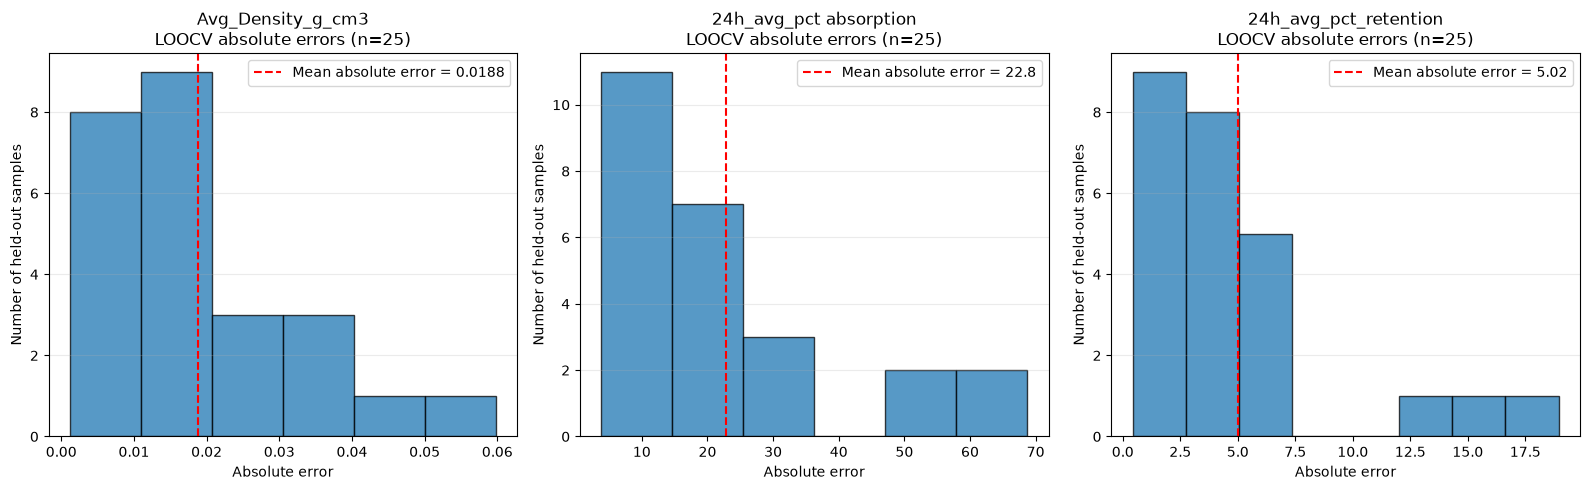

In [10]:
# Show the distribution of absolute errors across the 25 LOOCV folds.

absolute_errors = pd.DataFrame(index=model_data.index)
for target in target_cols:
    absolute_errors[target] = (
        model_data[target] - cv_predictions[f"{target} - LOOCV prediction"]
    ).abs()

fig, axes = plt.subplots(1, len(target_cols), figsize=(16, 5))

for ax, target in zip(axes, target_cols):
    errors = absolute_errors[target]
    ax.hist(errors, bins="auto", edgecolor="black", alpha=0.75)
    ax.axvline(
        errors.mean(),
        color="red",
        linestyle="--",
        label=f"Mean absolute error = {errors.mean():.3g}",
    )
    ax.set_title(f"{target}\nLOOCV absolute errors (n={len(errors)})")
    ax.set_xlabel("Absolute error")
    ax.set_ylabel("Number of held-out samples")
    ax.grid(axis="y", alpha=0.25)
    ax.legend()

fig.tight_layout()
plt.show()

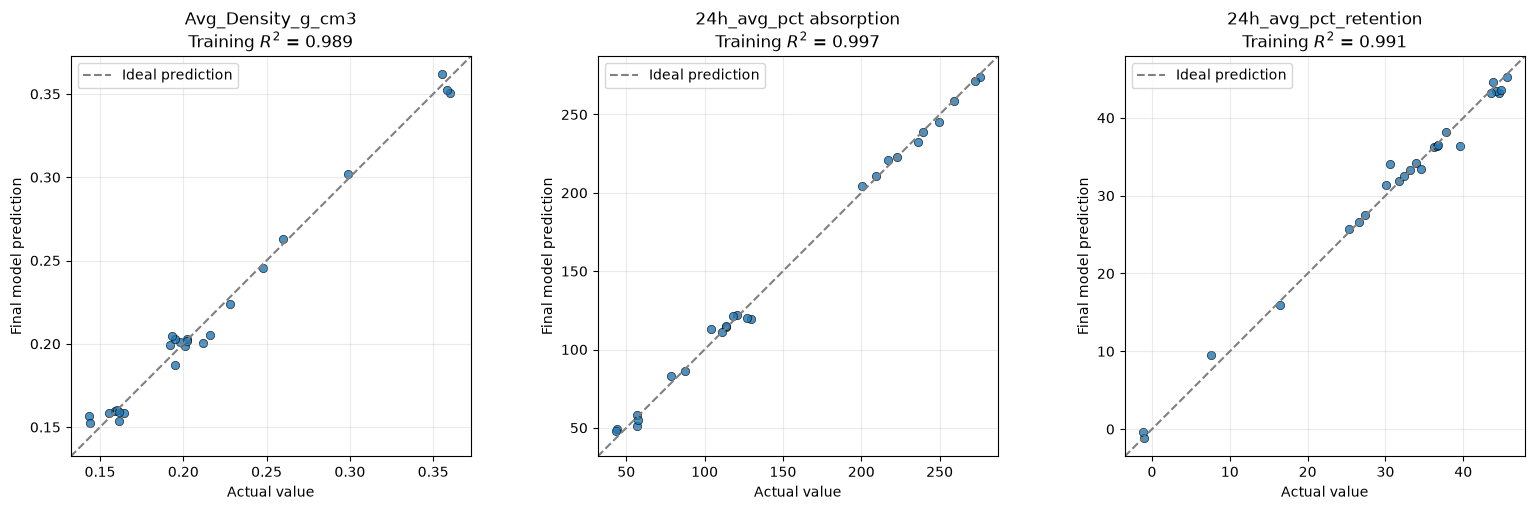

In [11]:
# Plot predictions from the final GPR estimators fitted on all 25 samples.
import matplotlib.pyplot as plt

training_predictions = pd.DataFrame(index=model_data.index)
for target in target_cols:
    training_predictions[target] = gpr_models[target].predict(X)

fig, axes = plt.subplots(1, len(target_cols), figsize=(16, 5))

for ax, target in zip(axes, target_cols):
    y_true = model_data[target]
    y_pred = training_predictions[target]
    training_r2 = r2_score(y_true, y_pred)
    lower = min(y_true.min(), y_pred.min())
    upper = max(y_true.max(), y_pred.max())
    padding = (upper - lower) * 0.05
    plot_min, plot_max = lower - padding, upper + padding

    ax.scatter(y_true, y_pred, alpha=0.8, edgecolor="black", linewidth=0.5)
    ax.plot(
        [plot_min, plot_max],
        [plot_min, plot_max],
        "--",
        color="gray",
        label="Ideal prediction",
    )
    ax.set_xlim(plot_min, plot_max)
    ax.set_ylim(plot_min, plot_max)
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(f"{target}\nTraining $R^2$ = {training_r2:.3f}")
    ax.set_xlabel("Actual value")
    ax.set_ylabel("Final model prediction")
    ax.grid(alpha=0.25)
    ax.legend()

fig.tight_layout()
plt.show()

In [12]:
# Formula constraints:
# - TEM: 5-8%.
# - Each chain extender (Joncryl, NC513, PEG-DE, NGDE): 0.7-3% when included; 0% when omitted.
# - Combined chain extender amount: no more than 6%.
# - Generate 100,000 valid candidate formulas.
import numpy as np

candidate_count = 100_000
chain_extender_cols = ["Joncryl", "NC513", "PEG-DE", "NGDE"]
feature_cols = ["TEM", *chain_extender_cols]
rng = np.random.default_rng(42)

candidate_chunks = []
collected = 0
while collected < candidate_count:
    batch_size = max(10_000, 2 * (candidate_count - collected))
    active_counts = rng.integers(1, len(chain_extender_cols) + 1, size=batch_size)
    active_order = rng.random((batch_size, len(chain_extender_cols))).argsort(axis=1)
    active_mask = active_order < active_counts[:, None]
    extender_amounts = rng.uniform(0.7, 3.0, size=(batch_size, len(chain_extender_cols)))
    extender_amounts = np.where(active_mask, extender_amounts, 0.0)

    valid_mask = extender_amounts.sum(axis=1) <= 6.0
    valid_batch = extender_amounts[valid_mask]
    candidate_chunks.append(valid_batch)
    collected += len(valid_batch)

extender_values = np.concatenate(candidate_chunks, axis=0)[:candidate_count]
candidate_set = pd.DataFrame(extender_values, columns=chain_extender_cols)
candidate_set.insert(0, "TEM", rng.uniform(5.0, 8.0, size=candidate_count))
candidate_set = candidate_set[feature_cols]

# Confirm the generated formulas satisfy every requested bound.
assert len(candidate_set) == candidate_count
assert candidate_set["TEM"].between(5.0, 8.0).all()
assert candidate_set[chain_extender_cols].sum(axis=1).le(6.0).all()
for col in chain_extender_cols:
    active = candidate_set[col].ne(0)
    assert candidate_set.loc[active, col].between(0.7, 3.0).all()

print(f"Generated {len(candidate_set):,} valid candidate formulas.")
print(candidate_set.head())
print("Maximum total chain extender:", candidate_set[chain_extender_cols].sum(axis=1).max())

Generated 100,000 valid candidate formulas.
        TEM   Joncryl     NC513    PEG-DE      NGDE
0  7.498286  0.000000  0.000000  2.198651  0.000000
1  6.711942  1.784903  0.787018  1.213481  0.724965
2  5.505915  0.850501  1.969780  2.903304  0.000000
3  5.838431  2.472247  0.000000  1.159775  0.000000
4  5.735430  2.128875  0.000000  0.000000  0.791036
Maximum total chain extender: 5.999979539311976


In [13]:
# Predict all three properties for every generated candidate formula.
candidate_predictions = candidate_set.copy()

for target in target_cols:
    candidate_predictions[f"predicted_{target}"] = gpr_models[target].predict(
        candidate_set[feature_cols]
    )

assert len(candidate_predictions) == candidate_count
assert all(f"predicted_{target}" in candidate_predictions.columns for target in target_cols)

print(f"Predictions generated for {len(candidate_predictions):,} candidate formulas.")
display(candidate_predictions.head())

Predictions generated for 100,000 candidate formulas.


,TEM,Joncryl,NC513,PEG-DE,NGDE,predicted_Avg_Density_g_cm3,predicted_24h_avg_pct absorption,predicted_24h_avg_pct_retention
0,7.498286,0.000000,0.000000,2.198651,0.000000,0.211892,263.930250,-1.427908
1,6.711942,1.784903,0.787018,1.213481,0.724965,0.214483,164.248133,28.815967
2,5.505915,0.850501,1.969780,2.903304,0.000000,0.232020,199.340182,35.024331
3,5.838431,2.472247,0.000000,1.159775,0.000000,0.215118,138.836635,29.186059
4,5.735430,2.128875,0.000000,0.000000,0.791036,0.215942,103.916927,27.661785


In [14]:
# Keep candidates that are not dominated on all three predicted properties.
# Objectives: minimize density; maximize 24h absorption and 24h retention.
density_col = "predicted_Avg_Density_g_cm3"
absorption_col = "predicted_24h_avg_pct absorption"
retention_col = "predicted_24h_avg_pct_retention"
objective_cols = [density_col, absorption_col, retention_col]
objective_values = candidate_predictions[objective_cols].to_numpy(dtype=float)
finite_mask = np.isfinite(objective_values).all(axis=1)
finite_indices = np.flatnonzero(finite_mask)
finite_values = objective_values[finite_mask]

# Keep one representative if multiple formulas have identical predicted objectives.
unique_values, first_positions = np.unique(finite_values, axis=0, return_index=True)
original_indices = finite_indices[first_positions]

# Sort by density ascending, then absorption and retention descending.
order = np.lexsort((-unique_values[:, 2], -unique_values[:, 1], unique_values[:, 0]))
sorted_values = unique_values[order]
sorted_indices = original_indices[order]
absorption_levels = np.unique(sorted_values[:, 1])
level_count = len(absorption_levels)
fenwick_max_retention = np.full(level_count + 1, -np.inf)
pareto_indices = []

for row, original_index in zip(sorted_values, sorted_indices):
    density, absorption, retention = row
    absorption_rank = np.searchsorted(absorption_levels, absorption)
    query_index = level_count - absorption_rank

    # Query the best retention among earlier candidates with at least this absorption.
    best_prior_retention = -np.inf
    index = query_index
    while index > 0:
        best_prior_retention = max(best_prior_retention, fenwick_max_retention[index])
        index -= index & -index

    if best_prior_retention < retention:
        pareto_indices.append(original_index)

    # Add this candidate to the prefix-maximum Fenwick tree.
    index = query_index
    while index <= level_count:
        fenwick_max_retention[index] = max(fenwick_max_retention[index], retention)
        index += index & -index

pareto_candidates = candidate_predictions.iloc[pareto_indices].copy()
assert len(pareto_candidates) > 0
assert pareto_candidates["TEM"].between(5.0, 8.0).all()
assert pareto_candidates[chain_extender_cols].sum(axis=1).le(6.0).all()

# These three frontier members show the single-objective extremes and trade-offs.
pareto_extremes = pd.concat(
    [
        pareto_candidates.loc[[pareto_candidates[density_col].idxmin()]],
        pareto_candidates.loc[[pareto_candidates[absorption_col].idxmax()]],
        pareto_candidates.loc[[pareto_candidates[retention_col].idxmax()]],
    ]
).drop_duplicates()

print(f"Found {len(pareto_candidates):,} Pareto-optimal formulas out of {len(candidate_predictions):,} candidates.")
print("Pareto-front extremes (lowest density, highest absorption, highest retention):")
display(pareto_extremes[feature_cols + objective_cols])
print("\nFirst 20 Pareto candidates, ordered by predicted density:")
display(
    pareto_candidates.sort_values(density_col)[feature_cols + objective_cols].head(20)
)

Found 114 Pareto-optimal formulas out of 100,000 candidates.
Pareto-front extremes (lowest density, highest absorption, highest retention):


,TEM,Joncryl,NC513,PEG-DE,NGDE,predicted_Avg_Density_g_cm3,predicted_24h_avg_pct absorption,predicted_24h_avg_pct_retention
33602,7.967423,1.195205,0.000000,2.828116,0.000000,0.148309,197.872791,41.030411
65322,7.990858,0.000000,0.000000,1.363412,0.000000,0.201917,281.044991,3.707913
82564,5.004008,0.000000,1.190539,0.000000,2.434799,0.328465,82.400401,46.458564



First 20 Pareto candidates, ordered by predicted density:


,TEM,Joncryl,NC513,PEG-DE,NGDE,predicted_Avg_Density_g_cm3,predicted_24h_avg_pct absorption,predicted_24h_avg_pct_retention
33602,7.967423,1.195205,0.000000,2.828116,0.0,0.148309,197.872791,41.030411
3475,7.982344,1.214672,0.000000,1.908033,0.0,0.148338,196.925830,42.546386
9421,7.994052,1.104685,0.000000,2.552930,0.0,0.149978,203.040008,43.258743
48689,7.984946,0.851359,2.738995,1.830220,0.0,0.151660,233.675577,35.426820
26191,7.994754,1.102542,0.000000,1.236263,0.0,0.151703,202.877462,43.584089
98210,7.953490,0.841701,2.964560,1.658972,0.0,0.152479,237.332799,35.416135
1955,7.987890,1.018809,2.570147,1.140126,0.0,0.153319,234.298487,36.808494
22309,7.925018,0.722941,2.788564,1.143174,0.0,0.153422,239.282245,36.135939
55700,7.979391,1.029388,0.000000,2.763521,0.0,0.154298,206.031525,42.396420
21398,7.922092,0.940514,2.600155,0.890985,0.0,0.155120,224.773359,37.125613
